# Análisis exploratorio — customer-details.xlsx

Primeros pasos: carga de datos, exploración inicial.

## 1. Importar librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Opciones de visualización
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 5)

## 2. Cargar los datos

El Excel tiene una hoja por año. Las cargamos todas y las unimos en un solo DataFrame,
agregando una columna `Anio` para poder distinguir el origen de cada fila.

In [2]:
ruta = "customer-details.xlsx"
hojas = pd.read_excel(ruta, sheet_name=None)  # dict {nombre_hoja: DataFrame}

for nombre, df in hojas.items():
    df["Anio"] = nombre

df = pd.concat(hojas.values(), ignore_index=True)

# La columna "Unnamed: 0" es un índice residual del Excel original, no aporta info
df = df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")])

df.shape

(43170, 7)

## 3. Primer vistazo

In [3]:
df.head()

,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID,Anio
0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079,2012
1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097,2012
2,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b,2012
3,121393,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e,2012
4,63164,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,2012


- `Income`: ingreso del cliente
- `Kidhome`: cantidad de niños en el hogar
- `Teenhome`: cantidad de adolescentes en el hogar
- `Dt_Customer`: fecha de alta como cliente
- `NumWebVisitsMonth`: visitas mensuales al sitio web
- `ID`: identificador único del cliente


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43170 entries, 0 to 43169
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Income             43170 non-null  int64         
 1   Kidhome            43170 non-null  int64         
 2   Teenhome           43170 non-null  int64         
 3   Dt_Customer        43170 non-null  datetime64[us]
 4   NumWebVisitsMonth  43170 non-null  int64         
 5   ID                 43170 non-null  str           
 6   Anio               43170 non-null  str           
dtypes: datetime64[us](1), int64(4), str(2)
memory usage: 2.3 MB


## 4. Calidad de los datos

Revisamos valores nulos, duplicados y estadísticas descriptivas básicas.

In [5]:
df.isnull().sum()

Income               0
Kidhome              0
Teenhome             0
Dt_Customer          0
NumWebVisitsMonth    0
ID                   0
Anio                 0
dtype: int64

In [6]:
# IDs duplicados (un mismo cliente podría aparecer en más de un año)
print("Filas totales:", len(df))
print("IDs únicos:", df['ID'].nunique())
print("IDs duplicados:", df['ID'].duplicated().sum())

Filas totales: 43170
IDs únicos: 43170
IDs duplicados: 0


In [7]:
df.describe()

,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth
count,43170.000000,43170.000000,43170.000000,43170,43170.000000
mean,93227.389622,1.004749,0.998633,2013-05-11 22:09:47.407922,16.591290
min,5841.000000,0.000000,0.000000,2012-01-01 00:00:00,1.000000
25%,49608.000000,0.000000,0.000000,2012-07-16 00:00:00,9.000000
50%,93009.500000,1.000000,1.000000,2013-03-01 00:00:00,17.000000
75%,136740.500000,2.000000,2.000000,2014-03-28 00:00:00,25.000000
max,180802.000000,2.000000,2.000000,2014-12-31 00:00:00,32.000000
std,50498.181989,0.815996,0.816008,NaN,9.241769


## 5. Primeras visualizaciones exploratorias

Con esto ya podemos empezar a ver la forma de los datos antes de profundizar en un análisis
más específico.

### Distribución del ingreso (`Income`)

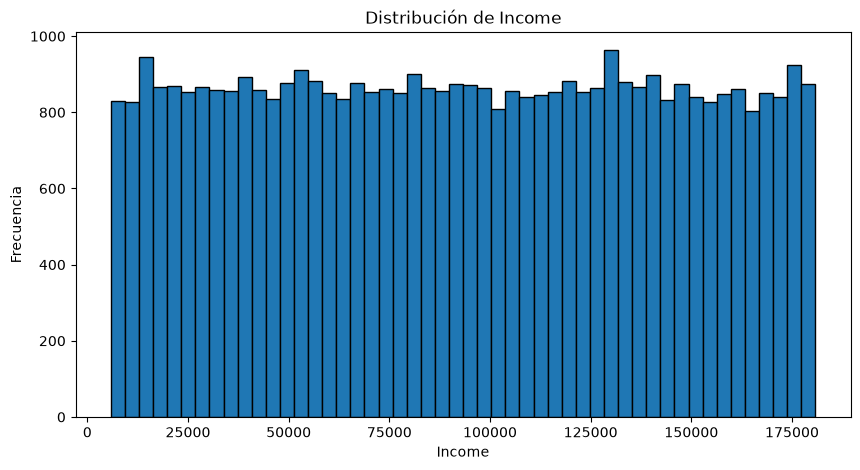

In [8]:
plt.hist(df['Income'], bins=50, edgecolor='black')
plt.title('Distribución de Income')
plt.xlabel('Income')
plt.ylabel('Frecuencia')
plt.show()

### Clientes nuevos por año (según la hoja de origen)

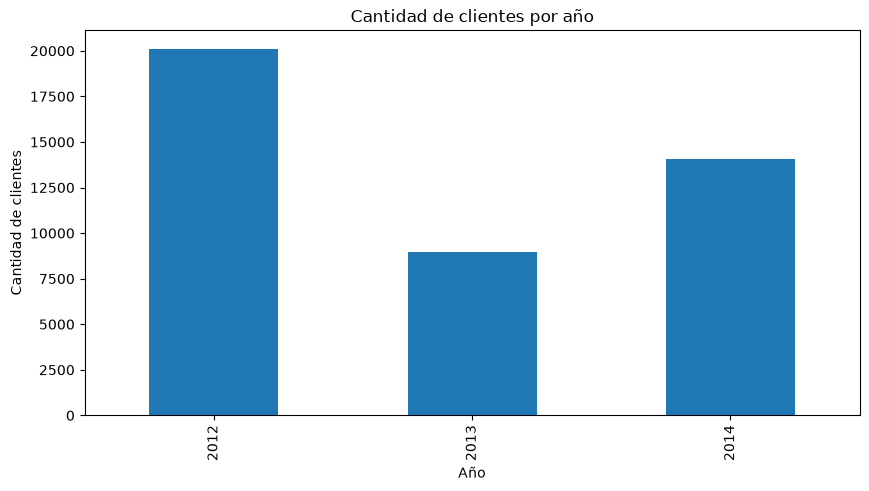

In [14]:
df['Anio'].value_counts().sort_index().plot(kind='bar')
plt.title('Cantidad de clientes por año')
plt.xlabel('Año')
plt.ylabel('Cantidad de clientes')
plt.show()

### Visitas web mensuales vs. Ingreso

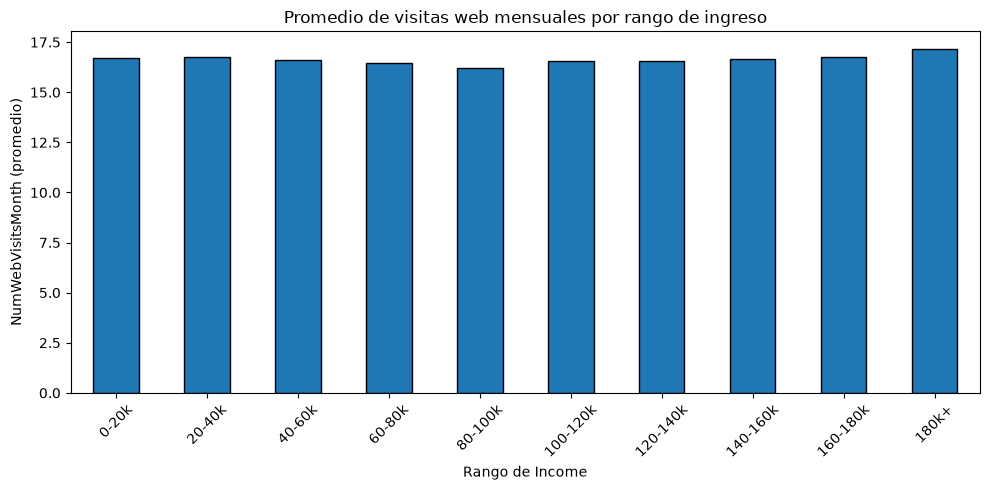

In [13]:
bins = [0, 20000, 40000, 60000, 80000, 100000, 120000, 140000, 160000, 180000, df['Income'].max() + 1]
labels = ['0-20k', '20-40k', '40-60k', '60-80k', '80-100k',
          '100-120k', '120-140k', '140-160k', '160-180k', '180k+']
df['IncomeBin'] = pd.cut(df['Income'], bins=bins, labels=labels, right=False)

promedio_visitas = df.groupby('IncomeBin')['NumWebVisitsMonth'].mean()

promedio_visitas.plot(kind='bar', edgecolor='black')
plt.title('Promedio de visitas web mensuales por rango de ingreso')
plt.xlabel('Rango de Income')
plt.ylabel('NumWebVisitsMonth (promedio)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Próximos pasos sugeridos

- Revisar outliers en `Income` (valores extremos que puedan distorsionar el análisis).
- Cruzar `Kidhome`/`Teenhome` con `Income` o `NumWebVisitsMonth`.
- Analizar antigüedad del cliente a partir de `Dt_Customer`.
- Definir la pregunta de negocio concreta que querés responder, para orientar el resto del análisis.

## Visitas vs Kids home

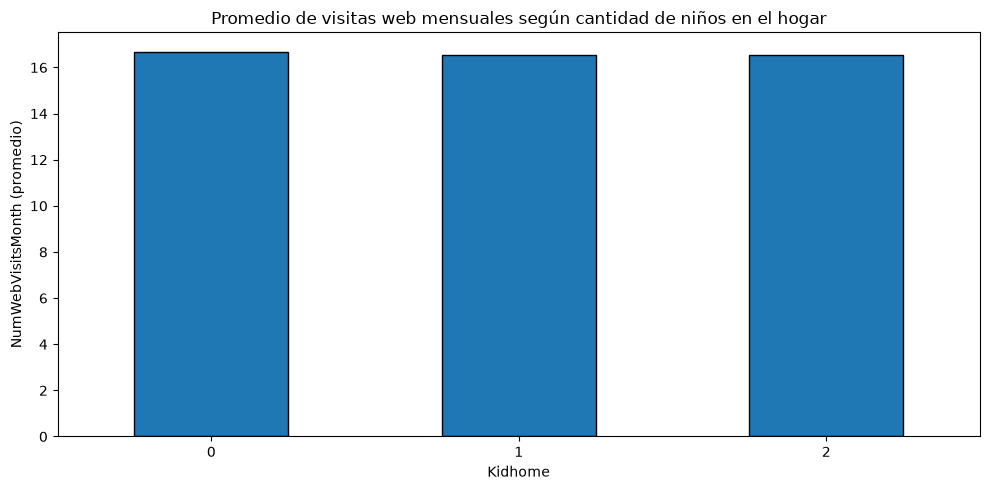

In [15]:
promedio_visitas_kidhome = df.groupby('Kidhome')['NumWebVisitsMonth'].mean()

promedio_visitas_kidhome.plot(kind='bar', edgecolor='black')
plt.title('Promedio de visitas web mensuales según cantidad de niños en el hogar')
plt.xlabel('Kidhome')
plt.ylabel('NumWebVisitsMonth (promedio)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## visitas vs kids por año

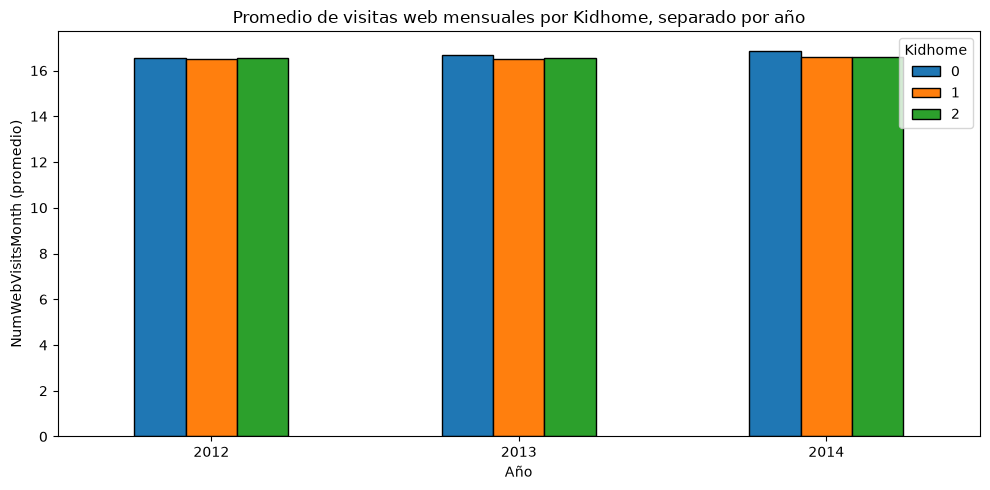

In [16]:
promedio_por_anio_kidhome = df.groupby(['Anio', 'Kidhome'])['NumWebVisitsMonth'].mean().unstack('Kidhome')

promedio_por_anio_kidhome.plot(kind='bar', edgecolor='black')
plt.title('Promedio de visitas web mensuales por Kidhome, separado por año')
plt.xlabel('Año')
plt.ylabel('NumWebVisitsMonth (promedio)')
plt.xticks(rotation=0)
plt.legend(title='Kidhome')
plt.tight_layout()
plt.show()

## visitas web vs teenshome por año

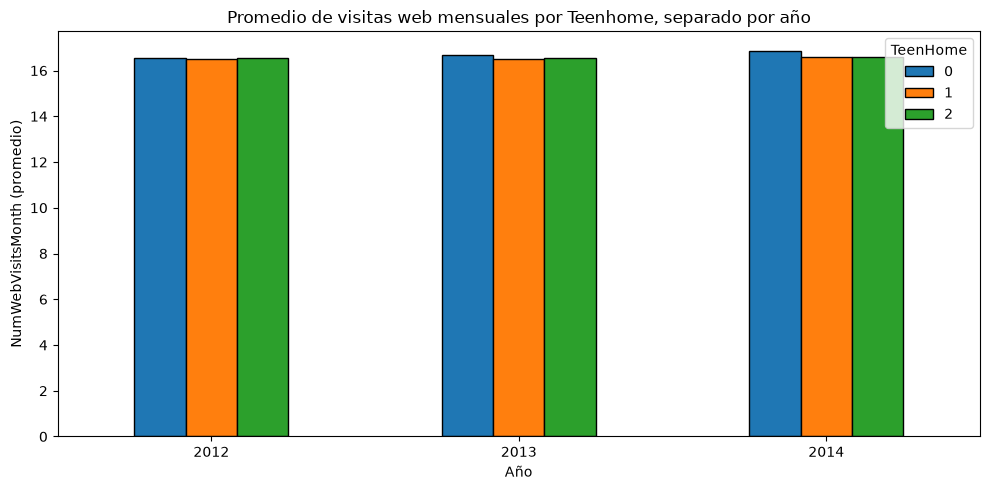

In [18]:
promedio_por_anio_Teenhome = df.groupby(['Anio', 'Teenhome'])['NumWebVisitsMonth'].mean().unstack('Teenhome')

promedio_por_anio_kidhome.plot(kind='bar', edgecolor='black')
plt.title('Promedio de visitas web mensuales por Teenhome, separado por año')
plt.xlabel('Año')
plt.ylabel('NumWebVisitsMonth (promedio)')
plt.xticks(rotation=0)
plt.legend(title='TeenHome')
plt.tight_layout()
plt.show()

### Boxplot de Income por Kidhome y por Teenhome

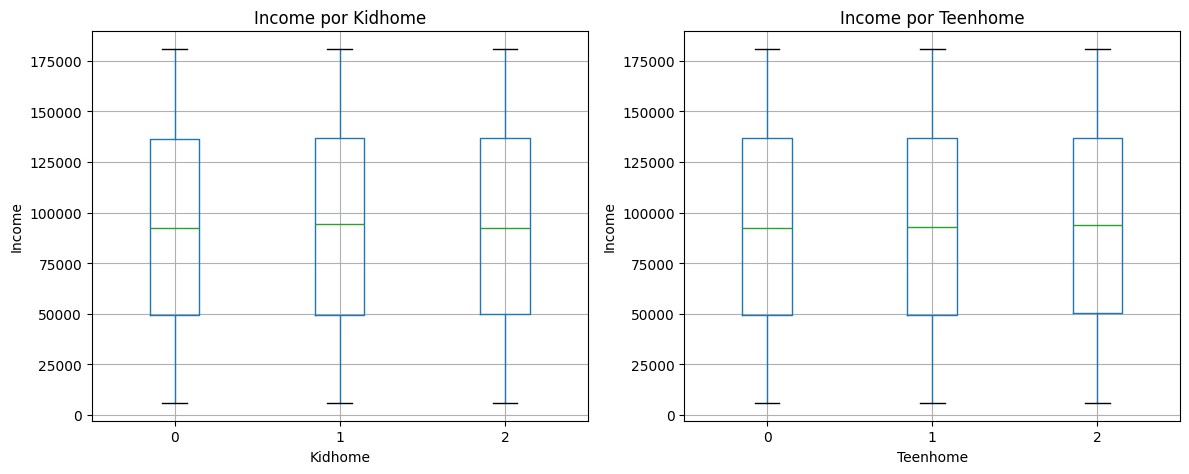

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df.boxplot(column='Income', by='Kidhome', ax=axes[0])
axes[0].set_title('Income por Kidhome')
axes[0].set_xlabel('Kidhome')
axes[0].set_ylabel('Income')

df.boxplot(column='Income', by='Teenhome', ax=axes[1])
axes[1].set_title('Income por Teenhome')
axes[1].set_xlabel('Teenhome')
axes[1].set_ylabel('Income')

plt.suptitle('')
plt.tight_layout()
plt.show()

### Mapa de correlación entre variables numéricas

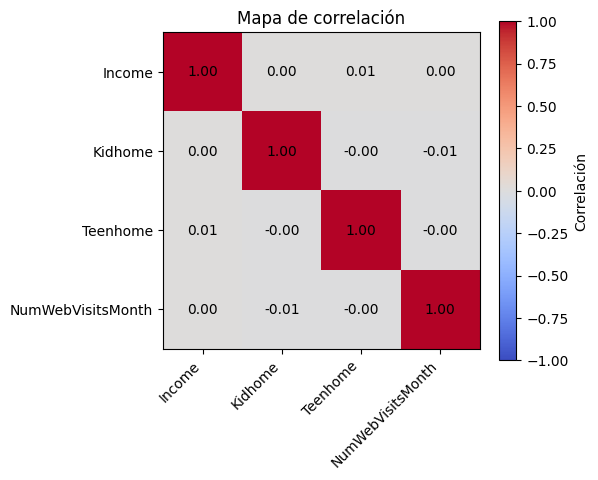

In [ ]:
columnas_num = ['Income', 'Kidhome', 'Teenhome', 'NumWebVisitsMonth']
corr = df[columnas_num].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(range(len(columnas_num)))
ax.set_yticks(range(len(columnas_num)))
ax.set_xticklabels(columnas_num, rotation=45, ha='right')
ax.set_yticklabels(columnas_num)

for i in range(len(columnas_num)):
    for j in range(len(columnas_num)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', color='black')

plt.colorbar(im, label='Correlación')
plt.title('Mapa de correlación')
plt.tight_layout()
plt.show()

### Antigüedad del cliente (`Dt_Customer`)

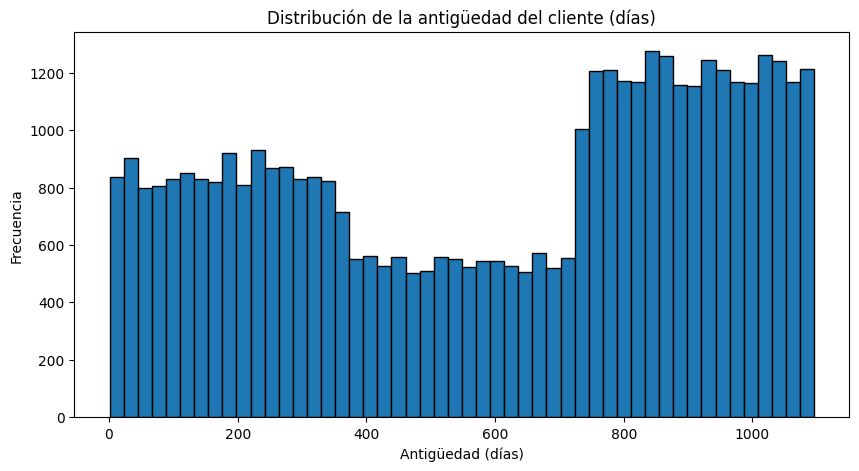

In [ ]:
referencia = df['Dt_Customer'].max() + pd.Timedelta(days=1)
df['Antiguedad_dias'] = (referencia - df['Dt_Customer']).dt.days

df['Antiguedad_dias'].plot(kind='hist', bins=50, edgecolor='black')
plt.title('Distribución de la antigüedad del cliente (días)')
plt.xlabel('Antigüedad (días)')
plt.ylabel('Frecuencia')
plt.show()